# Parte 1. Concatenar CSVs

In [10]:
import os
import pandas as pd

base_dir = "outputs/por_chico"

dfs = []

for root, dirs, files in os.walk(base_dir):
    for fname in files:
        if not fname.lower().endswith(".csv"):
            continue
        if not fname.startswith("df_results_"):
            continue

        filepath = os.path.join(root, fname)

        name_no_ext = os.path.splitext(fname)[0]
        name_core = name_no_ext.replace("df_results_", "", 1)

        partes = name_core.split("-")

        nombre = partes[0] if len(partes) > 0 else ""
        numero_audio = partes[1] if len(partes) > 1 else ""
        nivel_socio = partes[2] if len(partes) > 2 else ""

        df = pd.read_csv(filepath)

        df["nombre"] = nombre
        df["numero_audio"] = numero_audio
        df["nivel_socio"] = nivel_socio
        df["archivo_origen"] = fname
        df["carpeta_origen"] = os.path.basename(root)

        cols_first = ["nombre", "numero_audio", "nivel_socio", "archivo_origen", "carpeta_origen"]
        other_cols = [c for c in df.columns if c not in cols_first]
        df = df[cols_first + other_cols]

        dfs.append(df)

df_resultados_concat = pd.concat(dfs, ignore_index=True)

print("Filas:", len(df_resultados_concat))
print("Chicos únicos:", df_resultados_concat["nombre"].nunique())

Filas: 5088002
Chicos únicos: 24


# Parte 2. Guardar concatenado

In [ ]:
import os
import math

output_dir = "outputs/final_concats"
os.makedirs(output_dir, exist_ok=True)

# Límite seguro: 85 MB
max_size_bytes = 85 * 1024 * 1024

sample_n = min(10000, len(df_resultados_concat))

if sample_n == 0:
    print("DataFrame vacío.")
else:
    # --- Estimación inicial ---
    sample_df = df_resultados_concat.iloc[:sample_n]
    temp_path = os.path.join(output_dir, "_tmp_sample.csv")
    sample_df.to_csv(temp_path, index=False)
    sample_size = os.path.getsize(temp_path)
    os.remove(temp_path)

    bytes_per_row = sample_size / sample_n
    rows_per_file_est = max(1, int(max_size_bytes / bytes_per_row))

    print(f"Estimación inicial de filas por archivo: {rows_per_file_est}")

    start = 0
    part = 1
    total_rows = len(df_resultados_concat)

    while start < total_rows:
        end = min(start + rows_per_file_est, total_rows)

        # Primer intento
        chunk = df_resultados_concat.iloc[start:end]
        output_csv = os.path.join(output_dir, f"df_resultados_concat_part_{part}.csv")
        chunk.to_csv(output_csv, index=False)

        # Si se pasa, achicar hasta cumplir
        while os.path.getsize(output_csv) > max_size_bytes:
            os.remove(output_csv)

            # achicar un 10% cada vez
            new_rows = max(1, int((end - start) * 0.9))
            end = start + new_rows

            chunk = df_resultados_concat.iloc[start:end]
            chunk.to_csv(output_csv, index=False)

            # seguridad extra por si una sola fila fuera enorme
            if end == start + 1 and os.path.getsize(output_csv) > max_size_bytes:
                raise ValueError(
                    f"La fila en posición {start} sola supera el límite de {max_size_bytes} bytes."
                )

        final_size_mb = os.path.getsize(output_csv) / (1024 * 1024)
        print(
            f"Archivo {part}: filas {start} a {end-1} | "
            f"{end-start} filas | {final_size_mb:.2f} MB"
        )

        start = end
        part += 1

print("Archivos divididos correctamente.")

Estimación inicial de filas por archivo: 1272928
Archivo 1: filas 0 a 1145634 | 1145635 filas | 83.85 MB
Archivo 2: filas 1145635 a 2291269 | 1145635 filas | 82.89 MB


In [19]:
df = df_resultados_concat.copy()

# filas con al menos un NaN
df_nan = df[df.isna().any(axis=1)]

# chicos con NaN
chicos_con_nan = df_nan["nombre"].unique()

print("Chicos con al menos un NaN:")
print(chicos_con_nan)
print(f"\nCantidad: {len(chicos_con_nan)}")

Chicos con al menos un NaN:
[]

Cantidad: 0


# Análisis con todos los chicos

In [20]:
import numpy as np

df = df_resultados_concat.copy()

cols_elan = ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL"]
cols_diar = ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SPEECH"]

# SIL en Elan
df["Elan_SIL"] = (df[cols_elan].eq(0).all(axis=1)).astype(int)

# SIL en Diar
df["Diar_SIL"] = 1 - df["Diar_SPEECH"]

# Parte 4. Armar multilabel SIN ELE

In [21]:
labels = ["KCHI", "OCH", "MAL", "FEM", "SIL"]

y_true_multi = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_FEM", "Elan_MAL", "Elan_SIL"]
].values

y_pred_multi = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_FEM", "Diar_MAL", "Diar_SIL"]
].values

# Parte 5. Multilabel confusion + report

In [22]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report
import pandas as pd
import numpy as np

# índices de las clases que forman SPEECH
speech_indices = [labels.index(l) for l in ["KCHI", "OCH", "MAL", "FEM"]]

# crear columna SPEECH
y_true_speech = (y_true_multi[:, speech_indices].sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_multi[:, speech_indices].sum(axis=1) > 0).astype(int)

# agregar como nueva columna
y_true_multi = np.hstack([y_true_multi, y_true_speech.reshape(-1, 1)])
y_pred_multi = np.hstack([y_pred_multi, y_pred_speech.reshape(-1, 1)])

# agregar label
labels = labels + ["SPEECH"]

conf_matrix = multilabel_confusion_matrix(y_true_multi, y_pred_multi)

for i, label in enumerate(labels):
    print(f"\nMatriz para {label}:")
    print(conf_matrix[i])

print("\nReporte multilabel:")

# 🔽 CAMBIO ACÁ
report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report).T

# pasar a porcentaje con 1 decimal
cols = ['precision', 'recall', 'f1-score']
df_report[cols] = (df_report[cols] * 100).round(1).astype(str) + "%"

print(df_report)


Matriz para KCHI:
[[4273973  321746]
 [ 184328  307955]]

Matriz para OCH:
[[4392988  334614]
 [ 229218  131182]]

Matriz para MAL:
[[3713063  583970]
 [ 330926  460043]]

Matriz para FEM:
[[4612210  182323]
 [ 176535  116934]]

Matriz para SIL:
[[1345198  389807]
 [1127568 2225429]]

Matriz para SPEECH:
[[2447880  905117]
 [ 501023 1233982]]

Reporte multilabel:
             precision recall f1-score    support
KCHI             48.9%  62.6%    54.9%   492283.0
OCH              28.2%  36.4%    31.8%   360400.0
MAL              44.1%  58.2%    50.1%   790969.0
FEM              39.1%  39.8%    39.5%   293469.0
SIL              85.1%  66.4%    74.6%  3352997.0
SPEECH           57.7%  71.1%    63.7%  1735005.0
micro avg        62.2%  63.7%    63.0%  7025123.0
macro avg        50.5%  55.7%    52.4%  7025123.0
weighted avg     66.3%  63.7%    64.1%  7025123.0
samples avg      63.7%  64.9%    64.0%  7025123.0


## Análisis solo con los ACLEW 

In [23]:
import numpy as np
import pandas as pd
import re
from sklearn.metrics import multilabel_confusion_matrix, classification_report

# =========================
# 1) Copia y filtro de chicos
# =========================
df = df_resultados_concat.copy()

chicos_excluir = ["jeremiasc", "valentina", "brandona", "bautistad", "camilob"]

def extraer_chico_base(x):
    x = str(x).strip().lower()
    m = re.match(r"^(.*?)-a\d+-ns[mb]$", x)
    if m:
        return m.group(1)
    return x

df["chico"] = df["nombre"].apply(extraer_chico_base)

df = df[~df["chico"].isin(chicos_excluir)].copy()

print("Filas luego del filtro:", len(df))
print("Chicos excluidos que siguen presentes:", df["chico"].isin(chicos_excluir).sum())

# =========================
# 2) Definir orden base de etiquetas
# =========================
# IMPORTANTE:
# Este orden se usa para columnas, arrays, matrices y reporte.
# No cambiarlo en un lugar sin cambiarlo en todos.
labels_base = ["KCHI", "OCH", "MAL", "FEM"]

cols_elan = [f"Elan_{label}" for label in labels_base]
cols_diar = [f"Diar_{label}" for label in labels_base]

# =========================
# 3) Chequeo de columnas necesarias
# =========================
cols_necesarias = cols_elan + cols_diar + ["Diar_SPEECH", "nombre"]

faltantes = [col for col in cols_necesarias if col not in df.columns]

if faltantes:
    raise KeyError(f"Faltan estas columnas en df_resultados_concat: {faltantes}")

# =========================
# 4) Asegurar valores numéricos 0/1
# =========================
# Esto evita problemas si alguna columna viene como string, bool, NaN, etc.
for col in cols_elan + cols_diar + ["Diar_SPEECH"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Opcional: revisar NaN antes de calcular métricas
cols_metricas = cols_elan + cols_diar + ["Diar_SPEECH"]

filas_con_nan = df[cols_metricas].isna().any(axis=1).sum()
print("Filas con NaN en columnas de métricas:", filas_con_nan)

# Si hay NaN, las elimino para que sklearn no falle ni calcule mal
df = df.dropna(subset=cols_metricas).copy()

# Convertir a enteros
for col in cols_metricas:
    df[col] = df[col].astype(int)

print("Filas luego de eliminar NaN en métricas:", len(df))

# =========================
# 5) Crear SIL
# =========================
# Elan_SIL = 1 si no hay ninguna etiqueta de habla en ELAN
df["Elan_SIL"] = (df[cols_elan].eq(0).all(axis=1)).astype(int)

# Diar_SIL = 1 si Diar_SPEECH es 0
df["Diar_SIL"] = (1 - df["Diar_SPEECH"]).astype(int)

# =========================
# 6) Armar matrices multilabel base
#    Orden: KCHI, OCH, MAL, FEM
# =========================
y_true_base = df[cols_elan].values
y_pred_base = df[cols_diar].values

print("\nOrden de columnas ELAN usado:")
print(cols_elan)

print("\nOrden de columnas DIAR usado:")
print(cols_diar)

# =========================
# 7) Crear SPEECH a partir de KCHI/OCH/MAL/FEM
# =========================
# SPEECH = 1 si hay al menos una etiqueta activa entre KCHI/OCH/MAL/FEM
y_true_speech = (y_true_base.sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_base.sum(axis=1) > 0).astype(int)

# Chequeo opcional contra Diar_SPEECH original
diferencias_speech = (y_pred_speech != df["Diar_SPEECH"].values).sum()
print("\nDiferencias entre SPEECH recalculado desde Diar_* y Diar_SPEECH original:", diferencias_speech)

# =========================
# 8) Construir multilabel final
#    SIN SIL
#    Orden final: KCHI, OCH, MAL, FEM, SPEECH
# =========================
y_true_multi = np.column_stack([
    y_true_base,
    y_true_speech
])

y_pred_multi = np.column_stack([
    y_pred_base,
    y_pred_speech
])

labels = labels_base + ["SPEECH"]

print("\nshape y_true_multi:", y_true_multi.shape)
print("shape y_pred_multi:", y_pred_multi.shape)
print("labels:", labels)

# =========================
# 9) Matrices de confusión multilabel
# =========================
conf_matrix = multilabel_confusion_matrix(y_true_multi, y_pred_multi)

for i, label in enumerate(labels):
    print(f"\nMatriz para {label}:")
    print(conf_matrix[i])

# =========================
# 10) Reporte multilabel
# =========================
print("\nReporte multilabel:")

report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report).T

# Pasar métricas a porcentaje con 1 decimal
cols_porcentaje = ["precision", "recall", "f1-score"]
df_report[cols_porcentaje] = (
    df_report[cols_porcentaje] * 100
).round(1).astype(str) + "%"

print(df_report)

Filas luego del filtro: 3408002
Chicos excluidos que siguen presentes: 0
Filas con NaN en columnas de métricas: 0
Filas luego de eliminar NaN en métricas: 3408002

Orden de columnas ELAN usado:
['Elan_KCHI', 'Elan_OCH', 'Elan_MAL', 'Elan_FEM']

Orden de columnas DIAR usado:
['Diar_KCHI', 'Diar_OCH', 'Diar_MAL', 'Diar_FEM']

Diferencias entre SPEECH recalculado desde Diar_* y Diar_SPEECH original: 304103

shape y_true_multi: (3408002, 5)
shape y_pred_multi: (3408002, 5)
labels: ['KCHI', 'OCH', 'MAL', 'FEM', 'SPEECH']

Matriz para KCHI:
[[2917413  157311]
 [  88300  244978]]

Matriz para OCH:
[[2993418  166471]
 [ 155485   92628]]

Matriz para MAL:
[[3049672  109115]
 [ 153352   95863]]

Matriz para FEM:
[[2516294  273821]
 [ 233469  384418]]

Matriz para SPEECH:
[[1749356  353398]
 [ 313348  991900]]

Reporte multilabel:
             precision recall f1-score    support
KCHI             60.9%  73.5%    66.6%   333278.0
OCH              35.8%  37.3%    36.5%   248113.0
MAL              4

## ANÁLISIS POR NIVEL SOCIOECONÓMICO


In [24]:
df_frames = (
    df_resultados_concat
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

df_frames.sort_values("n_frames")

,nombre,numero_audio,nivel_socio,n_frames
23,verag,a2,nsm,168000
20,ummaq,a2,nsb,180000
19,manuelc,a2,nsm,180000
18,lucior,a2,nsm,180000
17,lucasyoelp,a2,nsb,180000
16,lisandroh,a2,nsm,180000
15,julietap,a1,nsm,180000
13,gaell,a2,nsb,180000
12,franciscop,a2,nsm,180000
22,valentinos,a1,nsb,180000


In [25]:
chicos_excluir = ["jeremiasc", "valentina", "brandona"]

df_frames = (
    df_resultados_concat[
        ~df_resultados_concat["nombre"].isin(chicos_excluir)
    ]
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

df_frames = df_frames.sort_values("n_frames")
df_frames

,nombre,numero_audio,nivel_socio,n_frames
20,verag,a2,nsm,168000
18,ummaq,a2,nsb,180000
17,manuelc,a2,nsm,180000
16,lucior,a2,nsm,180000
15,lucasyoelp,a2,nsb,180000
14,lisandroh,a2,nsm,180000
13,julietap,a1,nsm,180000
12,gaell,a2,nsb,180000
11,franciscop,a2,nsm,180000
19,valentinos,a1,nsb,180000


In [33]:
df_frames = (
    df_resultados_concat
    .groupby(["nombre", "numero_audio", "nivel_socio"])
    .size()
    .reset_index(name="n_frames")
)

# 1 frame = 0.01 segundos
df_frames["segundos"] = df_frames["n_frames"] * 0.01
df_frames["minutos"] = df_frames["segundos"] / 60

# formato mm:ss
df_frames["tiempo_mm_ss"] = pd.to_timedelta(df_frames["segundos"], unit="s").astype(str)

df_frames = df_frames.sort_values("n_frames")

df_frames

,nombre,numero_audio,nivel_socio,n_frames,segundos,minutos,tiempo_mm_ss
23,verag,a2,nsm,168000,1680.00,28.000000,0 days 00:28:00
20,ummaq,a2,nsb,180000,1800.00,30.000000,0 days 00:30:00
19,manuelc,a2,nsm,180000,1800.00,30.000000,0 days 00:30:00
18,lucior,a2,nsm,180000,1800.00,30.000000,0 days 00:30:00
17,lucasyoelp,a2,nsb,180000,1800.00,30.000000,0 days 00:30:00
16,lisandroh,a2,nsm,180000,1800.00,30.000000,0 days 00:30:00
15,julietap,a1,nsm,180000,1800.00,30.000000,0 days 00:30:00
13,gaell,a2,nsb,180000,1800.00,30.000000,0 days 00:30:00
12,franciscop,a2,nsm,180000,1800.00,30.000000,0 days 00:30:00
22,valentinos,a1,nsb,180000,1800.00,30.000000,0 days 00:30:00


In [34]:
df = df_resultados_concat.copy()

df_nsb = df[df["nivel_socio"] == "nsb"]
df_nsm = df[df["nivel_socio"] == "nsm"]

In [35]:
labels = ['KCHI', 'OCH', 'FEM', 'MAL', 'SIL']

y_true_nsb = df_nsb[
    ['Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_SIL']
].values

y_pred_nsb = df_nsb[
    ['Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SIL']
].values


y_true_nsm = df_nsm[
    ['Elan_KCHI', 'Elan_OCH', 'Elan_FEM', 'Elan_MAL', 'Elan_SIL']
].values

y_pred_nsm = df_nsm[
    ['Diar_KCHI', 'Diar_OCH', 'Diar_FEM', 'Diar_MAL', 'Diar_SIL']
].values

In [36]:
speech_idx = [0, 1, 2, 3]  # KCHI, OCH, FEM, MAL

def agregar_speech(y):
    speech = (y[:, speech_idx].sum(axis=1) > 0).astype(int)
    return np.hstack([y, speech.reshape(-1, 1)])

y_true_nsb = agregar_speech(y_true_nsb)
y_pred_nsb = agregar_speech(y_pred_nsb)

y_true_nsm = agregar_speech(y_true_nsm)
y_pred_nsm = agregar_speech(y_pred_nsm)

labels_full = labels + ["SPEECH"]

In [46]:
from sklearn.metrics import classification_report
import pandas as pd
import os

FRAME_SEC = 0.01  # 1 frame = 0.01 segundos

def generar_report_con_support_minutos(y_true, y_pred, labels_full):
    report = classification_report(
        y_true,
        y_pred,
        target_names=labels_full,
        zero_division=0,
        output_dict=True
    )

    df_report = pd.DataFrame(report).T

    # support está en frames; lo pasamos a minutos
    df_report["support_minutos"] = df_report["support"] * FRAME_SEC / 60

    # Formato
    df_report["precision"] = (df_report["precision"] * 100).round(1)
    df_report["recall"] = (df_report["recall"] * 100).round(1)
    df_report["f1-score"] = (df_report["f1-score"] * 100).round(1)

    df_report["support"] = df_report["support"].round(0).astype(int)
    df_report["support_minutos"] = df_report["support_minutos"].round(2)

    return df_report


# Crear reportes
df_report_nsb = generar_report_con_support_minutos(
    y_true_nsb,
    y_pred_nsb,
    labels_full
)

df_report_nsm = generar_report_con_support_minutos(
    y_true_nsm,
    y_pred_nsm,
    labels_full
)

# Mostrar en notebook
print("=== NSB ===")
display(df_report_nsb)

print("\n=== NSM ===")
display(df_report_nsm)


# Exportar a Excel
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "classification_report_nsb_nsm_con_tiempo.xlsx")

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_report_nsb.to_excel(writer, sheet_name="NSB")
    df_report_nsm.to_excel(writer, sheet_name="NSM")

print(f"Excel exportado en: {output_path}")

=== NSB ===


,precision,recall,f1-score,support,support_minutos
KCHI,40.4,72.0,51.8,229744,38.29
OCH,30.3,45.3,36.3,240470,40.08
FEM,38.4,56.3,45.6,390196,65.03
MAL,32.7,40.6,36.2,142584,23.76
SIL,87.6,57.2,69.2,1857437,309.57
SPEECH,52.0,75.7,61.7,902563,150.43
micro avg,56.8,61.1,58.9,3762994,627.17
macro avg,46.9,57.9,50.1,3762994,627.17
weighted avg,65.3,61.1,60.5,3762994,627.17
samples avg,58.4,59.8,58.7,3762994,627.17



=== NSM ===


,precision,recall,f1-score,support,support_minutos
KCHI,64.6,54.3,59.0,262539,43.76
OCH,21.0,18.6,19.7,119930,19.99
FEM,51.0,59.9,55.1,400773,66.80
MAL,48.3,39.1,43.3,150885,25.15
SIL,82.9,77.8,80.3,1495560,249.26
SPEECH,66.8,66.1,66.5,832442,138.74
micro avg,69.2,66.8,68.0,3262129,543.69
macro avg,55.8,52.6,54.0,3262129,543.69
weighted avg,69.5,66.8,68.0,3262129,543.69
samples avg,70.0,70.9,70.2,3262129,543.69


Excel exportado en: outputs\classification_report_nsb_nsm_con_tiempo.xlsx


In [48]:
report_nsb = classification_report(
    y_true_nsb, y_pred_nsb,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

report_nsm = classification_report(
    y_true_nsm, y_pred_nsm,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

df_comp = pd.DataFrame({
    "nsb_f1": {k: v["f1-score"] for k, v in report_nsb.items() if k in labels_full},
    "nsm_f1": {k: v["f1-score"] for k, v in report_nsm.items() if k in labels_full},
})

df_comp["diff"] = df_comp["nsm_f1"] - df_comp["nsb_f1"]
df_comp

,nsb_f1,nsm_f1,diff
KCHI,0.517969,0.589900,0.071931
OCH,0.362903,0.197264,-0.165639
FEM,0.456406,0.551143,0.094737
MAL,0.362064,0.432607,0.070543
SIL,0.692060,0.802657,0.110598
SPEECH,0.616504,0.664527,0.048023


In [49]:
from sklearn.metrics import classification_report
import pandas as pd
import os

FRAME_SEC = 0.01  # 1 frame = 0.01 segundos

report_nsb = classification_report(
    y_true_nsb, y_pred_nsb,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

report_nsm = classification_report(
    y_true_nsm, y_pred_nsm,
    target_names=labels_full,
    output_dict=True,
    zero_division=0
)

df_comp = pd.DataFrame({
    "nsb_f1": {k: v["f1-score"] for k, v in report_nsb.items() if k in labels_full},
    "nsm_f1": {k: v["f1-score"] for k, v in report_nsm.items() if k in labels_full},
})

df_comp["diff"] = df_comp["nsm_f1"] - df_comp["nsb_f1"]

# diferencia de support en minutos: NSM - NSB
df_comp["diff_support_minutos"] = (
    (
        pd.Series({k: v["support"] for k, v in report_nsm.items() if k in labels_full})
        -
        pd.Series({k: v["support"] for k, v in report_nsb.items() if k in labels_full})
    )
    * FRAME_SEC / 60
)

# opcional: redondear
df_comp["nsb_f1"] = df_comp["nsb_f1"].round(4)
df_comp["nsm_f1"] = df_comp["nsm_f1"].round(4)
df_comp["diff"] = df_comp["diff"].round(4)
df_comp["diff_support_minutos"] = df_comp["diff_support_minutos"].round(2)

display(df_comp)

# exportar a Excel
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "comparacion_f1_nsb_nsm_con_diff_tiempo.xlsx")

df_comp.to_excel(output_path, sheet_name="comparacion")

print(f"Excel exportado en: {output_path}")

,nsb_f1,nsm_f1,diff,diff_support_minutos
KCHI,0.5180,0.5899,0.0719,5.47
OCH,0.3629,0.1973,-0.1656,-20.09
FEM,0.4564,0.5511,0.0947,1.76
MAL,0.3621,0.4326,0.0705,1.38
SIL,0.6921,0.8027,0.1106,-60.31
SPEECH,0.6165,0.6645,0.0480,-11.69


Excel exportado en: outputs\comparacion_f1_nsb_nsm_con_diff_tiempo.xlsx


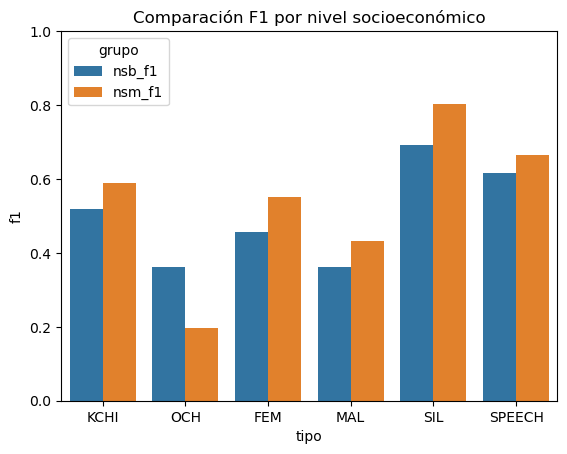

In [50]:
df_plot = df_comp.reset_index().rename(columns={"index": "tipo"})

import seaborn as sns
import matplotlib.pyplot as plt

df_plot_melt = df_plot.melt(
    id_vars="tipo",
    value_vars=["nsb_f1", "nsm_f1"],
    var_name="grupo",
    value_name="f1"
)

sns.barplot(data=df_plot_melt, x="tipo", y="f1", hue="grupo")

plt.title("Comparación F1 por nivel socioeconómico")
plt.ylim(0, 1)
plt.show()

# Parte 6. Multilabel → Single label

## REPORTE SINGLE LABEL

In [42]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# orden single-label correcto
labels_single = ["KCHI", "OCH", "MAL", "FEM", "SIL"]

# construir matrices base
y_true_base = df[
    ["Elan_KCHI", "Elan_OCH", "Elan_MAL", "Elan_FEM", "Elan_SIL"]
].values

y_pred_base = df[
    ["Diar_KCHI", "Diar_OCH", "Diar_MAL", "Diar_FEM", "Diar_SIL"]
].values

def multilabel_exclusivo_a_singlelabel(y_multilabel):
    single_labels = []
    for row in y_multilabel:
        indices = np.where(row == 1)[0]
        if len(indices) == 0:
            single_labels.append(-1)
        elif len(indices) == 1:
            single_labels.append(indices[0])
        else:
            # si hubiera más de una clase positiva en una fila "exclusiva",
            # tomar la primera y dejar advertencia conceptual
            single_labels.append(indices[0])
    return np.array(single_labels)

y_true = multilabel_exclusivo_a_singlelabel(y_true_base)
y_pred = multilabel_exclusivo_a_singlelabel(y_pred_base)

valid_indices = (y_true != -1) & (y_pred != -1)
y_true = y_true[valid_indices]
y_pred = y_pred[valid_indices]

print("\nReporte single-label:")

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(labels_single))),
    target_names=labels_single,
    zero_division=0,
    output_dict=True
)

df_report_single = pd.DataFrame(report).T

cols = ["precision", "recall", "f1-score"]
df_report_single[cols] = (df_report_single[cols] * 100).round(1).astype(str) + "%"

print(df_report_single)


Reporte single-label:
             precision recall f1-score       support
KCHI             48.9%  65.9%    56.1%  4.674320e+05
OCH              27.5%  29.0%    28.2%  3.002000e+05
MAL              36.8%  46.6%    41.1%  2.299320e+05
FEM              40.7%  60.6%    48.7%  6.052590e+05
SIL              85.5%  70.6%    77.4%  3.081745e+06
accuracy         65.0%  65.0%    65.0%  6.500843e-01
macro avg        47.9%  54.5%    50.3%  4.684568e+06
weighted avg     70.0%  65.0%    66.6%  4.684568e+06


# Parte 7. Matriz de confusión global 

## PRECISIÓN

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labels_idx = list(range(len(labels)))

# matriz de conteos
cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)

# precision: normalizada por columnas
cm_precision = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="pred")

# sacar SPEECH solo del gráfico
if "SPEECH" in labels:
    idx_speech = labels.index("SPEECH")
    idx_keep = [i for i in range(len(labels)) if i != idx_speech]

    cm_counts_plot = cm_counts[np.ix_(idx_keep, idx_keep)]
    cm_precision_plot = cm_precision[np.ix_(idx_keep, idx_keep)]
    labels_plot = [labels[i] for i in idx_keep]
else:
    cm_counts_plot = cm_counts
    cm_precision_plot = cm_precision
    labels_plot = labels

cm_counts_df = pd.DataFrame(cm_counts_plot, index=labels_plot, columns=labels_plot)
cm_precision_df = pd.DataFrame(cm_precision_plot, index=labels_plot, columns=labels_plot)

annot = (
    (cm_precision_df * 100).round(1).astype(str)
    + "%"
    + "\n"
    + cm_counts_df.astype(int).astype(str)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_precision_df,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=False
)

plt.title("Matriz de confusión global (Precision, sin SPEECH)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_precision_sin_speech.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## RECALL 

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

labels_idx = list(range(len(labels)))

# matriz de conteos
cm_counts = confusion_matrix(y_true, y_pred, labels=labels_idx)

# recall: normalizada por filas
cm_recall = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize="true")

# sacar SPEECH solo del gráfico
if "SPEECH" in labels:
    idx_speech = labels.index("SPEECH")
    idx_keep = [i for i in range(len(labels)) if i != idx_speech]

    cm_counts_plot = cm_counts[np.ix_(idx_keep, idx_keep)]
    cm_recall_plot = cm_recall[np.ix_(idx_keep, idx_keep)]
    labels_plot = [labels[i] for i in idx_keep]
else:
    cm_counts_plot = cm_counts
    cm_recall_plot = cm_recall
    labels_plot = labels

cm_counts_df = pd.DataFrame(cm_counts_plot, index=labels_plot, columns=labels_plot)
cm_recall_df = pd.DataFrame(cm_recall_plot, index=labels_plot, columns=labels_plot)

annot = (
    (cm_recall_df * 100).round(1).astype(str)
    + "%"
    + "\n"
    + cm_counts_df.astype(int).astype(str)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_recall_df,
    annot=annot,
    fmt="",
    cmap="Greens",
    cbar=False
)

plt.title("Matriz de confusión global (Recall, sin SPEECH)")
plt.ylabel("Verdaderas (Elan)")
plt.xlabel("Predichas (Diar)")

plt.savefig(
    "outputs/final_concats/matriz_confusion_global_recall_sin_speech.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Parte 8. Gráficos

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

os.makedirs("outputs/final_concats", exist_ok=True)

def plot_metrica(df_metrics, metrica, color, filename):
    df_plot = df_metrics.copy()

    # Convertir por si viene como string tipo "56.3%"
    if df_plot[metrica].dtype == "object":
        df_plot[metrica] = (
            df_plot[metrica]
            .astype(str)
            .str.replace("%", "", regex=False)
        )
        df_plot[metrica] = pd.to_numeric(df_plot[metrica], errors="coerce")

    # Detectar si está en escala 0-1 o 0-100
    max_val = df_plot[metrica].max()

    if max_val <= 1:
        df_plot[metrica + "_plot"] = df_plot[metrica] * 100
    else:
        df_plot[metrica + "_plot"] = df_plot[metrica]

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        x="Tipo",
        y=metrica + "_plot",
        data=df_plot,
        color=color,
        errorbar=None
    )

    plt.title(f"{metrica} por Tipo")
    plt.ylim(0, 100)
    plt.ylabel(metrica)
    plt.xlabel("Tipo")

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=4,
            fontsize=10
        )

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Gráfico guardado en: {filename}")

In [ ]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

# clases del análisis original single-label
# orden original de codificación:
# 0=KCHI, 1=OCH, 2=FEM, 3=MAL, 4=SIL
labels_base = ["KCHI", "OCH", "FEM", "MAL", "SIL"]

# filtrar válidos
valid_indices = (y_true != -1) & (y_pred != -1)
y_true_f = y_true[valid_indices]
y_pred_f = y_pred[valid_indices]

# binarizar clases base
classes_idx = list(range(len(labels_base)))  # [0,1,2,3,4]
y_true_multi_base = label_binarize(y_true_f, classes=classes_idx)
y_pred_multi_base = label_binarize(y_pred_f, classes=classes_idx)

# SPEECH = 1 si la clase es KCHI, OCH, FEM o MAL
speech_indices = [0, 1, 2, 3]

y_true_speech = (y_true_multi_base[:, speech_indices].sum(axis=1) > 0).astype(int)
y_pred_speech = (y_pred_multi_base[:, speech_indices].sum(axis=1) > 0).astype(int)

# construir multilabel final SIN SIL y en el orden deseado:
# KCHI, OCH, MAL, FEM, SPEECH
y_true_multi = np.column_stack([
    y_true_multi_base[:, 0],  # KCHI
    y_true_multi_base[:, 1],  # OCH
    y_true_multi_base[:, 3],  # MAL
    y_true_multi_base[:, 2],  # FEM
    y_true_speech             # SPEECH
])

y_pred_multi = np.column_stack([
    y_pred_multi_base[:, 0],  # KCHI
    y_pred_multi_base[:, 1],  # OCH
    y_pred_multi_base[:, 3],  # MAL
    y_pred_multi_base[:, 2],  # FEM
    y_pred_speech             # SPEECH
])

labels = ["KCHI", "OCH", "MAL", "FEM", "SPEECH"]

print("shape y_true_multi:", y_true_multi.shape)
print("shape y_pred_multi:", y_pred_multi.shape)
print("labels:", labels)

report = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=labels,
    output_dict=True,
    zero_division=0
)

df_metrics = (
    pd.DataFrame(report)
    .transpose()
    .reset_index()
    .rename(columns={
        "index": "Tipo",
        "precision": "Precisión",
        "recall": "Recall",
        "f1-score": "F1-score",
        "support": "Support"
    })
)

filas_excluir = ["micro avg", "macro avg", "weighted avg", "samples avg"]
df_metrics = df_metrics[~df_metrics["Tipo"].isin(filas_excluir)].copy()

print(df_metrics)

In [ ]:
# asegurar orden consistente (CORRECTO)
orden = ["KCHI", "OCH", "MAL", "FEM", "SPEECH"]

df_metrics["Tipo"] = pd.Categorical(
    df_metrics["Tipo"],
    categories=orden,
    ordered=True
)
df_metrics = df_metrics.sort_values("Tipo").copy()

# un solo color por métrica
color_precision = sns.color_palette("Blues", 5)[3]
color_recall = sns.color_palette("Greens", 5)[3]
color_f1 = sns.color_palette("Reds", 5)[3]

plot_metrica(
    df_metrics,
    "Precisión",
    color_precision,
    "outputs/final_concats/precision_multilabel.png"
)

plot_metrica(
    df_metrics,
    "Recall",
    color_recall,
    "outputs/final_concats/recall_multilabel.png"
)

plot_metrica(
    df_metrics,
    "F1-score",
    color_f1,
    "outputs/final_concats/f1_multilabel.png"
)

# Parte 10. Ranking por chico

In [ ]:
df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv", low_memory=False)

print(df.columns.tolist())

In [ ]:
import pandas as pd
import re

tipos_para_ranking = ["FEM", "MAL", "KCHI", "OCH"]

df = pd.read_csv(r"outputs\df_metrics_todos_los_chicos.csv", low_memory=False)

# Limpiar posibles espacios en nombres de columnas
df.columns = df.columns.str.strip()

# =========================
# 0) Limpieza
# =========================
df["F1-score"] = pd.to_numeric(df["F1-score"], errors="coerce")
df["Support"] = pd.to_numeric(df["Support"], errors="coerce")

df_rank = df[df["Tipo"].isin(tipos_para_ranking)].copy()

# Extraer nombre base del chico desde strings tipo:
# alma-a1-nsb -> alma
# verag-a2-nsm -> verag
def extraer_chico_base(x):
    x = str(x).strip().lower()
    m = re.match(r"^(.*?)-a\d+-ns[mb]$", x)
    if m:
        return m.group(1)
    return x

df_rank["chico"] = df_rank["name"].apply(extraer_chico_base)

# =========================
# 1) Promedio por chico y tipo
# =========================
df_por_tipo = (
    df_rank
    .groupby(["chico", "Tipo"], as_index=False)
    .agg(
        f1_promedio=("F1-score", "mean"),
        support_tipo=("Support", "sum")
    )
)

# =========================
# 2) Pivotear F1
# =========================
df_pivot = df_por_tipo.pivot(
    index="chico",
    columns="Tipo",
    values="f1_promedio"
).reset_index()

df_pivot = df_pivot.rename(columns={
    "FEM": "f1_FEM",
    "MAL": "f1_MAL",
    "KCHI": "f1_KCHI",
    "OCH": "f1_OCH"
})

# Asegurar columnas aunque falte alguna
for col in ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]:
    if col not in df_pivot.columns:
        df_pivot[col] = pd.NA

# =========================
# 3) Promedio total
# =========================
columnas_f1 = ["f1_FEM", "f1_MAL", "f1_KCHI", "f1_OCH"]
df_pivot["f1_promedio_total"] = df_pivot[columnas_f1].mean(axis=1)

# =========================
# 4) Metadata + Support por chico
# =========================
meta = (
    df_rank
    .groupby("chico", as_index=False)
    .agg(
        ns_code=("ns_code", lambda s: s.dropna().iloc[0] if not s.dropna().empty else pd.NA),
        support_total=("Support", "sum")
    )
)

# Cada muestra equivale a 0.01 segundos
meta["tiempo_total_segundos"] = meta["support_total"] * 0.01
meta["tiempo_total_minutos"] = meta["tiempo_total_segundos"] / 60

df_final = df_pivot.merge(meta, on="chico", how="left")

# =========================
# 5) Map manual de corpus por chico
# =========================
map_corpus = {
    "alma": "raw_ROS",
    "amparol": "raw_ROS",
    "angelinap": "raw_ROS",
    "bautista": "segunda-vuelta/random",
    "bautistad": "segunda-vuelta/random",
    "biancak": "raw_ROS_HV",
    "brandona": "segunda-vuelta/highVol",
    "camilob": "segunda-vuelta/random",
    "camilop": "raw_ROS_HV",
    "dantec": "raw_ROS",
    "dantep": "raw_ROS_HV",
    "dianag": "raw_ROS_HV",
    "florl": "segunda-vuelta/random",
    "francescam": "raw_ROS_HV",
    "franciscop": "raw_ROS_HV",
    "gaell": "raw_ROS",
    "jeremiasc": "segunda-vuelta/highVol",
    "julietap": "raw_ROS_HV",
    "lisandroh": "raw_ROS",
    "lucasyoelp": "raw_ROS_HV",
    "lucior": "raw_ROS",
    "manuelc": "raw_ROS",
    "ummaq": "raw_ROS",
    "valentina": "segunda-vuelta/highVol",
    "valentinos": "raw_ROS",
    "verag": "raw_ROS_HV",
}

df_final["corpus"] = df_final["chico"].map(map_corpus)

# =========================
# 6) Ranking
# =========================
df_final = df_final.sort_values("f1_promedio_total", ascending=False).reset_index(drop=True)
df_final["ranking"] = df_final.index + 1

# =========================
# 7) Orden final
# =========================
df_final = df_final[
    [
        "ranking",
        "chico",
        "corpus",
        "ns_code",
        "support_total",
        "tiempo_total_segundos",
        "tiempo_total_minutos",
        "f1_promedio_total",
        "f1_FEM",
        "f1_MAL",
        "f1_KCHI",
        "f1_OCH"
    ]
]

# =========================
# 8) Revisar faltantes
# =========================
faltan_corpus = df_final[df_final["corpus"].isna()]
if not faltan_corpus.empty:
    print("\nNombres sin corpus asignado:")
    print(faltan_corpus[["chico"]].drop_duplicates().sort_values("chico"))

# =========================
# 9) Guardar
# =========================
df_final.to_csv(
    "outputs/ranking_f1_por_chico.csv",
    index=False,
    encoding="utf-8-sig"
)

print(df_final.head(10))

In [ ]:
df_final